## Basics

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr
from matplotlib.patches import Ellipse
from datetime import datetime

date = datetime.today().strftime('%Y%m%d')

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [16]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp

In [17]:
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in mpl.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Data Loading & Preprocessing

In [18]:
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")
totalmetriccomparison = totalmetriccomparison[~totalmetriccomparison['MBON'].isin(['VT999036', 'R76B09'])]

metric_mode = "MATCHED"

locomotor_metrics_all = [
    'Log2 Bout Speed ratio_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
    'Bout Number Index_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR',
    'Average height climbed_Δg_Falling', 'Straightness Index_Δg_Falling',
    'Bout speed_Δg_Falling', 'Duration of bouts_Δg_Falling',
    'Number of Bouts_Δg_Falling', 'Max velocity_Δg_Falling', 'Fall number_ΔΔ_Falling'
]

locomotor_metrics_matched = [
    'Log2 Bout Speed ratio_Hg_OSAR', 
    'Bout Duration ratio_Hg_OSAR', 'Bout Number Index_Hg_OSAR',
    'Max Velocity ratio_Hg_OSAR',
    'Log2 Bout Speed ratio_Hg_Falling', 
    'Bout Duration ratio_Hg_Falling', 'Bout Number index_Hg_Falling',
    'Max Velocity ratio_Hg_Falling'
]

locomotor_metrics = locomotor_metrics_matched if metric_mode == "MATCHED" else locomotor_metrics_all
valence_metrics = ['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']

responder_names = {'ACR': 'GtACR1', 'Chrimson2': 'CsChrimson'}
cluster_colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
fixed_k = 2
results = {}

for resp, display_name in responder_names.items():
    df = totalmetriccomparison[totalmetriccomparison['responder'] == resp].reset_index(drop=True)
    mbons = df['MBON'].values
    X = df[locomotor_metrics].fillna(0).values
    X_scaled = StandardScaler().fit_transform(X)

    mean_loco_g = df[locomotor_metrics].abs().mean(axis=1).values
    mean_pref_g = df[valence_metrics].abs().mean(axis=1).values

    pca = PCA()
    pc_scores = pca.fit_transform(X_scaled)
    loadings = pd.DataFrame(pca.components_.T, index=locomotor_metrics,
                            columns=[f'PC{i+1}' for i in range(len(locomotor_metrics))])

    sil_scores = {}
    for k in [2, 3, 4]:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(pc_scores[:, :2])
        sil_scores[k] = silhouette_score(pc_scores[:, :2], labels)

    cluster_labels = KMeans(n_clusters=fixed_k, random_state=42, n_init=10).fit_predict(pc_scores[:, :2])
    Z = linkage(X_scaled, method='complete', metric='euclidean')
    coph_corr, _ = cophenet(Z, pdist(X_scaled, metric='euclidean'))

    corrs = {}
    for val_met, val_name in zip(valence_metrics, ['PI', 'LAI']):
        vals = df[val_met].values
        for pc_idx in range(3):
            r, p = pearsonr(vals, pc_scores[:, pc_idx])
            corrs[f'{val_name}_PC{pc_idx+1}'] = (r, p)

    results[resp] = dict(display_name=display_name, mbons=mbons, df=df,
        X_scaled=X_scaled, pca=pca, pc_scores=pc_scores, loadings=loadings,
        mean_loco_g=mean_loco_g, mean_pref_g=mean_pref_g,
        sil_scores=sil_scores, optimal_k=fixed_k,
        cluster_labels=cluster_labels, Z=Z, coph_corr=coph_corr, corrs=corrs)

print(f"Metric mode: {metric_mode} ({len(locomotor_metrics)} metrics)")
for resp, r in results.items():
    print(f"\n{'='*60}\n{r['display_name']}\n{'='*60}")
    print("Explained variance: " + ", ".join([f"PC{i+1}: {v*100:.1f}%" for i, v in enumerate(r['pca'].explained_variance_ratio_[:4])]))
    print(f"Using k={fixed_k}")
    print("Silhouette scores: " + ", ".join([f"k={k}: {s:.3f}" for k, s in r['sil_scores'].items()]))
    print(f"Cophenetic correlation: {r['coph_corr']:.3f}")
    print("Correlations:")
    for key, (rv, pv) in r['corrs'].items():
        print(f"  {key}: r={rv:.3f}, p={pv:.4f}")
    print("Cluster assignments:")
    for c in range(r['optimal_k']):
        members = r['mbons'][r['cluster_labels'] == c]
        print(f"  Cluster {c}: {', '.join(members)}")
    print("Loadings (PC1-PC4):")
    print(r['loadings'][['PC1','PC2','PC3','PC4']].to_string())

Metric mode: MATCHED (8 metrics)

GtACR1
Explained variance: PC1: 31.4%, PC2: 18.8%, PC3: 16.5%, PC4: 11.3%
Using k=2
Silhouette scores: k=2: 0.472, k=3: 0.388, k=4: 0.396
Cophenetic correlation: 0.482
Correlations:
  PI_PC1: r=0.049, p=0.7975
  PI_PC2: r=0.333, p=0.0719
  PI_PC3: r=0.034, p=0.8572
  LAI_PC1: r=0.082, p=0.6671
  LAI_PC2: r=0.351, p=0.0573
  LAI_PC3: r=0.379, p=0.0388
Cluster assignments:
  Cluster 0: SS52050, SS77383, SS77442, SS80896
  Cluster 1: MB018B, MB077B, MB082C, MB093C, MB112C, MB210B, MB242A, MB310C, MB319C, MB323B, MB434B, SS01188, SS01298, SS01308, SS46348, SS67662, SS67741, SS75199, SS75200, SS77450, SS80958, SS81353, SS81521, SS86947, SS95118, SS97567
Loadings (PC1-PC4):
                                       PC1       PC2       PC3       PC4
Log2 Bout Speed ratio_Hg_OSAR    -0.330405  0.290235  0.423206 -0.268920
Bout Duration ratio_Hg_OSAR       0.472871 -0.302319 -0.132787  0.241268
Bout Number Index_Hg_OSAR         0.461378 -0.217382  0.380720 -0.2189

## Figure 1: Scree Plot

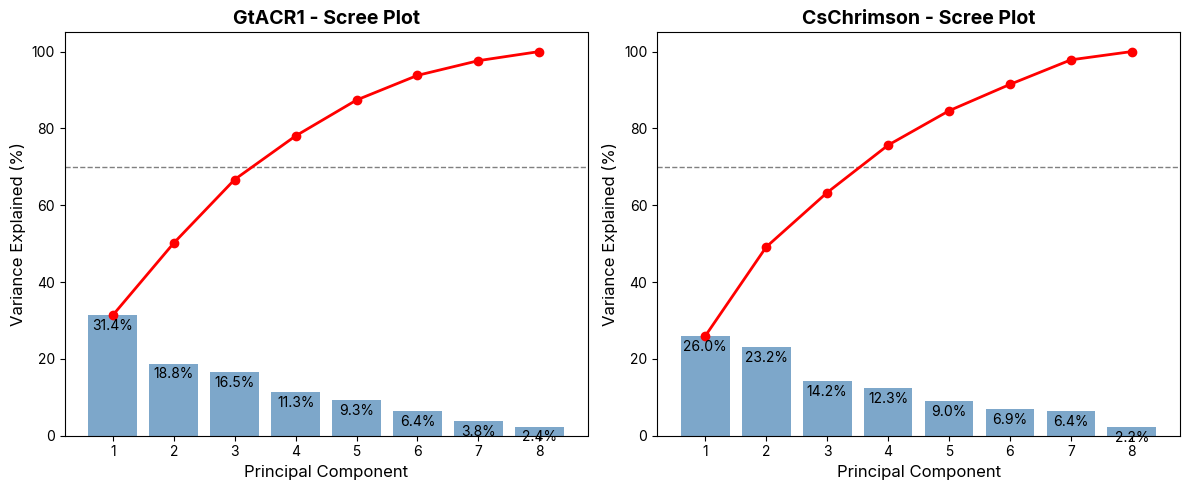

In [46]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, resp in enumerate(['ACR', 'Chrimson2']):
    r = results[resp]
    var = r['pca'].explained_variance_ratio_ * 100
    ax = axes[col]
    bars = ax.bar(range(1, len(var)+1), var, color='steelblue', alpha=0.7)
    ax.plot(range(1, len(var)+1), np.cumsum(var), 'ro-', linewidth=2)
    for bar, v in zip(bars, var):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()-1, f'{v:.1f}%', ha='center', va='top', fontsize=10)
    ax.set_xlabel('Principal Component', fontsize=12)
    ax.set_ylabel('Variance Explained (%)', fontsize=12)
    ax.set_title(f'{r["display_name"]} - Scree Plot', fontweight='bold', fontsize=14)
    ax.set_xticks(range(1, len(var)+1))
    ax.axhline(y=70, color = "gray", linestyle = "--", linewidth = 1, zorder = 1)
plt.tight_layout()
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\screeplot.svg", bbox_inches="tight")
plt.show()

## Figure 2: PC Loadings Heatmaps

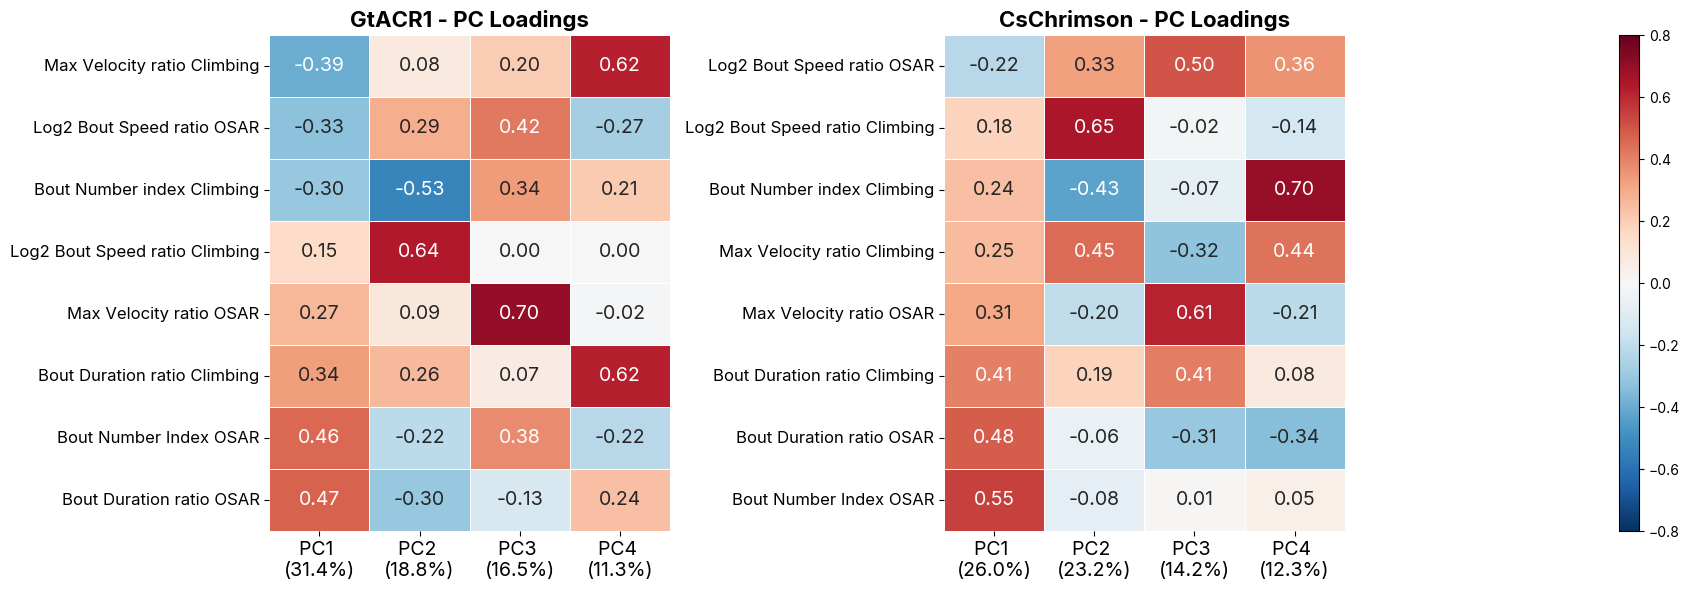

In [45]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, axes = plt.subplots(1, 3, figsize=(17, 6), gridspec_kw={'width_ratios': [1, 1, 0.05]})
short_names = [m.replace('_Hg_', ' ').replace('_Δg_', ' ').replace('_ΔΔ_', ' ').replace('Falling', 'Climbing') for m in locomotor_metrics]

for col, resp in enumerate(['ACR', 'Chrimson2']):
    r = results[resp]
    var = r['pca'].explained_variance_ratio_ * 100
    hm_data = r['loadings'][['PC1','PC2','PC3','PC4']].copy()
    hm_data.index = short_names
    hm_data = hm_data.iloc[hm_data['PC1'].argsort()]
    hm_data.columns = [f'PC{i+1} \n({var[i]:.1f}%)' for i in range(4)]
    sns.heatmap(hm_data, ax=axes[col], cmap='RdBu_r', center=0, vmin=-0.8, vmax=0.8,
                annot=True, fmt='.2f', annot_kws= {'fontsize':14}, linewidths=0.5, cbar=False)
    axes[col].set_title(f'{r["display_name"]} - PC Loadings', fontweight='bold', fontsize=16)
    axes[col].set_ylabel('')
    axes[col].set_xticklabels(axes[col].get_xticklabels(), fontsize = 14)
    axes[col].set_yticklabels(axes[col].get_yticklabels(), fontsize = 12)

fig.colorbar(axes[0].collections[0], cax=axes[2])
plt.tight_layout()
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\images\\loadings.svg", bbox_inches="tight")
plt.show()

## Figure 3: Biplots by Mean |Locomotor g|

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for col, resp in enumerate(['ACR', 'Chrimson2']):
    r = results[resp]
    ax = axes[col]
    pc = r['pc_scores']

    sc = ax.scatter(pc[:, 0], pc[:, 1], c=r['mean_loco_g'], cmap='plasma',
                    s=80, zorder=5, edgecolors='k', linewidth=0.5, vmin=0, vmax=0.7)
    plt.colorbar(sc, ax=ax, label='Mean |locomotor g|')

    for i, mbon in enumerate(r['mbons']):
        ax.annotate(mbon, (pc[i, 0], pc[i, 1]), fontsize=7, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    for c in range(r['optimal_k']):
        mask = r['cluster_labels'] == c
        if mask.sum() < 3:
            continue
        x, y = pc[mask, 0], pc[mask, 1]
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
        w, h = 2 * np.sqrt(np.maximum(vals, 0) * 5.991)
        ax.add_patch(Ellipse((x.mean(), y.mean()), w, h, angle=angle,
                             facecolor=cluster_colors[c], alpha=0.08,
                             edgecolor=cluster_colors[c], linewidth=2))

    ax.axhline(0, color='grey', linestyle='--', alpha=0.3)
    ax.axvline(0, color='grey', linestyle='--', alpha=0.3)
    ax.set_xlabel(f'PC1 ({r["pca"].explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({r["pca"].explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.set_title(f'{r["display_name"]} - Biplot (colored by |locomotor g|)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## Figure 4: Biplots by Mean |Preference g|

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for col, resp in enumerate(['ACR', 'Chrimson2']):
    r = results[resp]
    ax = axes[col]
    pc = r['pc_scores']

    sc = ax.scatter(pc[:, 0], pc[:, 1], c=r['mean_pref_g'], cmap='viridis',
                    s=80, zorder=5, edgecolors='k', linewidth=0.5)
    plt.colorbar(sc, ax=ax, label='Mean |preference g|')

    for i, mbon in enumerate(r['mbons']):
        ax.annotate(mbon, (pc[i, 0], pc[i, 1]), fontsize=7, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    for c in range(r['optimal_k']):
        mask = r['cluster_labels'] == c
        if mask.sum() < 3:
            continue
        x, y = pc[mask, 0], pc[mask, 1]
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
        w, h = 2 * np.sqrt(np.maximum(vals, 0) * 5.991)
        ax.add_patch(Ellipse((x.mean(), y.mean()), w, h, angle=angle,
                             facecolor=cluster_colors[c], alpha=0.08,
                             edgecolor=cluster_colors[c], linewidth=2))

    ax.axhline(0, color='grey', linestyle='--', alpha=0.3)
    ax.axvline(0, color='grey', linestyle='--', alpha=0.3)
    ax.set_xlabel(f'PC1 ({r["pca"].explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({r["pca"].explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.set_title(f'{r["display_name"]} - Biplot (colored by |preference g|)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## Figure 5: Valence vs PC Correlations

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for row, resp in enumerate(['ACR', 'Chrimson2']):
    r = results[resp]
    pc = r['pc_scores']

    for col_idx, (val_met, val_name) in enumerate(zip(valence_metrics, ['PI', 'LAI'])):
        ax = axes[row, col_idx]
        vals = r['df'][val_met].values

        ax.scatter(pc[:, 0], vals, s=60, color='k', alpha=0.7)
        m, b = np.polyfit(pc[:, 0], vals, 1)
        x_range = np.linspace(pc[:, 0].min(), pc[:, 0].max(), 100)
        ax.plot(x_range, m * x_range + b, color='red', linewidth=2)

        rv, pv = r['corrs'][f'{val_name}_PC1']
        ax.annotate(f'r = {rv:.3f}\np = {pv:.4f}', (0.05, 0.95), xycoords='axes fraction',
                    va='top', fontweight='bold', fontsize=12)

        ax.set_xlabel(f'PC1 ({r["pca"].explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
        ax.set_ylabel(val_met, fontsize=12)
        ax.set_title(f'{r["display_name"]} - {val_name} vs PC1', fontweight='bold', fontsize=14)
        ax.axhline(0, color='grey', linestyle='--', alpha=0.3)
        ax.axvline(0, color='grey', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Figure 6: Clustering Evaluation

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, resp in enumerate(['ACR', 'Chrimson2']):
    r = results[resp]

    ax = axes[0, col]
    ks = list(r['sil_scores'].keys())
    scores = list(r['sil_scores'].values())
    bars = ax.bar(ks, scores, color='steelblue', alpha=0.7)
    bars[scores.index(max(scores))].set_color('#D55E00')
    ax.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax.set_ylabel('Silhouette Score', fontsize=12)
    ax.set_title(f'{r["display_name"]} - Silhouette Scores', fontweight='bold', fontsize=14)
    ax.set_xticks(ks)

    ax = axes[1, col]
    dendrogram(r['Z'], labels=r['mbons'], leaf_rotation=90, leaf_font_size=8, ax=ax)
    ax.set_title(f'{r["display_name"]} - Dendrogram (Complete, coph={r["coph_corr"]:.2f})', fontweight='bold', fontsize=14)
    ax.set_ylabel('Distance', fontsize=12)

plt.tight_layout()
plt.show()